In [ ]:
### Importing necessary libraries
import argparse

import EoN
import matplotlib.gridspec as gridspec
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
import xgi
from scipy.ndimage import zoom, gaussian_filter
from joblib import Parallel, delayed

from src import *

set_fonts()

In [ ]:
### Defining the range for eps and del
eps = np.linspace(0.1, 3, 100)
dels = np.linspace(0.1, 3, 100)

### Empty list to store results from the loop
results = []

### Number of nodes
N = 10000
k = 10

### Setting R0 based on the simplest case (BC with well-mixed interactions)
joint_dist1 = create_comm(0.8)
joint_dist2 = create_comm(-0.8)

R0 = 1.1
a = eps @ joint_dist1 @ dels.T
b = eps @ joint_dist2 @ dels.T

gam = 0.1
beta = IBC_beta(a, b, R0, gam, k, 0, 0.5)

args = {"N": N, "k": k, "beta": beta, "gam": gam}


def run_epidemic(e, r, real, args):
    ### Redefining params
    N = args["N"]
    k = args["k"]
    beta = args["beta"]
    gam = args["gam"]

    ### Finding community sizes
    size_comm1 = int(r * N)
    size_comm2 = int(N - size_comm1)

    ### Creating the distributions and population
    _, comm1 = create_comm(0.8, samplesize=size_comm1)
    _, comm2 = create_comm(-0.8, samplesize=size_comm2)

    ### Store the eps and dels for each individual in a population array
    population = np.concatenate([comm1, comm2], axis=0)

    ### Create the graph
    G = uniform_HPPM(N, 2, k, e, r)
    G = xgi.convert.to_graph(G)
    G = nx.DiGraph(G)

    ### Assign each edge the transmission probability
    e_attr = dict()
    for i, j in G.edges:
        e_attr[(i, j)] = {"weights": population[i][1] * population[j][0]}
    nx.set_edge_attributes(G, e_attr)

    ### Seed the initial infected as 5 percent of the whole population
    first_infected = np.random.choice(range(0, N), size=int(N * 0.05), replace=False)

    ### Run EoN.fast_SIR
    sim = EoN.fast_SIR(
        G,
        beta,
        gam,
        initial_infecteds=first_infected,
        transmission_weight="weights",
        return_full_data=True,
    )

    ### Find nodes which were in comm1 and comm2
    node_list_comm1 = list(range(0, size_comm1))
    node_list_comm2 = list(range(size_comm1, size_comm1 + size_comm2))

    ### Extract data from simulation summary
    _, D1 = sim.summary(node_list_comm1)
    _, D2 = sim.summary(node_list_comm2)

    ### return the results
    return {
        "real": real,
        "e": e,
        "r": r,
        "R1": D1["R"][-1] / size_comm1,
        "R2": D2["R"][-1] / size_comm2,
        "Rt": (D1["R"][-1] + D2["R"][-1]) / N,
    }


n_cores = 64

results = Parallel(n_jobs=n_cores)(
    delayed(run_epidemic)(e, r, real, args)
    for e in np.linspace(-1, 1, 101)
    for r in np.linspace(0.01, 0.99, 51)
    for real in range(100)
)

### Create a csv file to store results
pl.DataFrame(results).write_csv("../Data/Fig5_data_wBP.csv")

/var/folders/v6/wt8vcjk93bl1q0rlwdkdgt0w0000gq/T/ipykernel_56626/992013430.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(51, 101)


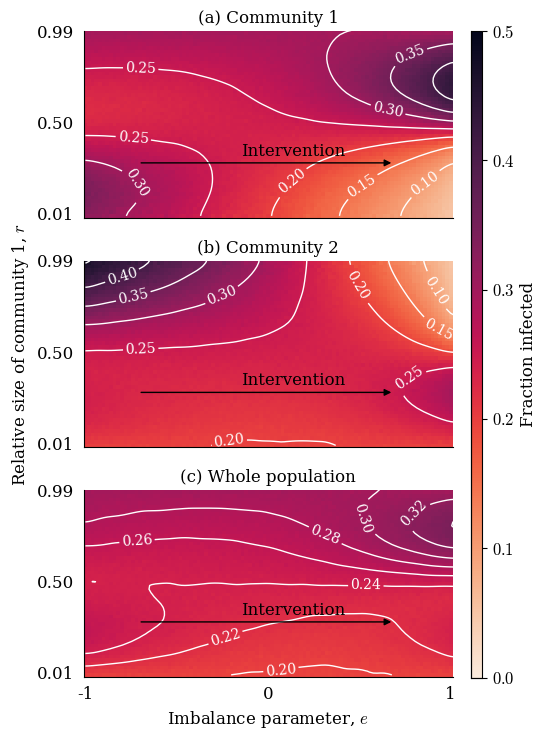

In [ ]:
cls = sns.color_palette("blend:#479FF8,#DA3B26", n_colors=4)

filepath = "Data/Fig5_data_wBP.csv"

results_fig5 = pl.read_csv(filepath)
results_R1 = (
    results_fig5.group_by(["e", "r"])
    .agg(pl.mean("R1"))
    .sort(["e", "r"])
    .pivot(on="e", index="r", values="R1")
)
results_R2 = (
    results_fig5.group_by(["e", "r"])
    .agg(pl.mean("R2"))
    .sort(["e", "r"])
    .pivot(on="e", index="r", values="R2")
)
results_Rt = (
    results_fig5.group_by(["e", "r"])
    .agg(pl.mean("Rt"))
    .sort(["e", "r"])
    .pivot(on="e", index="r", values="Rt")
)

fig = plt.figure(figsize=(5.5, 7.5))

ax_heat_R1 = fig.add_subplot(3, 1, 1)  # heatmap

data_matrix = results_R1.drop("r")
y_labels = [
    r"0.01",
    *["" for i in range(24)],
    r"0.50",
    *["" for i in range(24)],
    r"0.99",
]
x_labels = [r"", *["" for i in range(49)], r"", *["" for i in range(49)], r""]
sns.heatmap(
    data_matrix,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cmap="rocket_r",
    ax=ax_heat_R1,
    vmin=0.0,
    vmax=0.5,
    rasterized=True,
    cbar=False,
)

ax_heat_R1.set_aspect("equal", adjustable="box")
ax_heat_R1.set_ylim(ax_heat_R1.get_ylim()[::-1])

data_smooth = gaussian_filter(data_matrix, sigma=2)
x_smooth = np.linspace(0.5, data_matrix.shape[1] + 0.5, data_smooth.shape[1])
y_smooth = np.linspace(0.5, data_matrix.shape[0] + 0.5, data_smooth.shape[0])

cs = ax_heat_R1.contour(
    x_smooth, y_smooth, data_smooth, colors="white", linestyles="-", linewidths=1
)
ax_heat_R1.clabel(cs, inline=True)
ax_heat_R1.tick_params(left=False, bottom=False)

plt.setp(ax_heat_R1.get_yticklabels(), rotation=0)

ax_heat_R1.annotate(
    "",
    xy=(85, 15),
    xytext=(15, 15),
    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1),
    zorder=6,
)
ax_heat_R1.text(43, 17, "Intervention", color="black", fontsize=12)
ax_heat_R1.set_title("(a) Community 1")  # heatmap


ax_heat_R2 = fig.add_subplot(3, 1, 2)  # heatmap

data_matrix = results_R2.drop("r")
y_labels = [
    r"0.01",
    *["" for i in range(24)],
    r"0.50",
    *["" for i in range(24)],
    r"0.99",
]
x_labels = [r"", *["" for i in range(49)], r"", *["" for i in range(49)], r""]
sns.heatmap(
    data_matrix,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cmap="rocket_r",
    ax=ax_heat_R2,
    vmin=0.0,
    vmax=0.5,
    rasterized=True,
    cbar=False,
)

ax_heat_R2.set_aspect("equal", adjustable="box")
ax_heat_R2.set_ylim(ax_heat_R2.get_ylim()[::-1])

data_smooth = gaussian_filter(data_matrix, sigma=2)
x_smooth = np.linspace(0.5, data_matrix.shape[1] + 0.5, data_smooth.shape[1])
y_smooth = np.linspace(0.5, data_matrix.shape[0] + 0.5, data_smooth.shape[0])
cs = ax_heat_R2.contour(
    x_smooth, y_smooth, data_smooth, colors="white", linestyles="-", linewidths=1
)

ax_heat_R2.clabel(cs, inline=True)
ax_heat_R2.tick_params(left=False, bottom=False)

ax_heat_R2.set_ylabel(r"Relative size of community 1, $r$")
plt.setp(ax_heat_R2.get_yticklabels(), rotation=0)

ax_heat_R2.annotate(
    "",
    xy=(85, 15),
    xytext=(15, 15),
    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1),
    zorder=6,
)
ax_heat_R2.text(43, 17, "Intervention", color="black", fontsize=12)
ax_heat_R2.set_title("(b) Community 2")  # heatmap

ax_heat_Rt = fig.add_subplot(3, 1, 3)  # heatmap

data_matrix = results_Rt.drop("r")
y_labels = [
    r"0.01",
    *["" for i in range(24)],
    r"0.50",
    *["" for i in range(24)],
    r"0.99",
]
x_labels = [r"-1", *["" for i in range(49)], r"0", *["" for i in range(49)], r"1"]
sns.heatmap(
    data_matrix,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cmap="rocket_r",
    ax=ax_heat_Rt,
    vmin=0.0,
    vmax=0.5,
    rasterized=True,
    cbar=False,
)

ax_heat_Rt.set_aspect("equal", adjustable="box")
ax_heat_Rt.set_ylim(ax_heat_Rt.get_ylim()[::-1])

data_smooth = gaussian_filter(data_matrix, sigma=2)
x_smooth = np.linspace(0.5, data_matrix.shape[1] + 0.5, data_smooth.shape[1])
y_smooth = np.linspace(0.5, data_matrix.shape[0] + 0.5, data_smooth.shape[0])
cs = ax_heat_Rt.contour(
    x_smooth, y_smooth, data_smooth, colors="white", linestyles="-", linewidths=1
)
ax_heat_Rt.clabel(cs, inline=True)
ax_heat_Rt.tick_params(left=False, bottom=False)

ax_heat_Rt.set_xlabel(r"Imbalance parameter, $e$")
plt.setp(ax_heat_Rt.get_yticklabels(), rotation=0)

ax_heat_Rt.annotate(
    "",
    xy=(85, 15),
    xytext=(15, 15),
    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1),
    zorder=6,
)
ax_heat_Rt.text(43, 17, "Intervention", color="black", fontsize=12)
ax_heat_Rt.set_title("(c) Whole population")  # heatmap

# add a single common colorbar
fig.subplots_adjust(right=1)  # make room on the right
cbar_ax = fig.add_axes([0.87, 0.09, 0.02, 0.862])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap="rocket_r", norm=plt.Normalize(vmin=0.0, vmax=0.5))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r"Fraction infected")
cbar.set_ticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
cbar.ax.set_yticklabels([r"$0.0$", r"$0.1$", r"$0.2$", r"$0.3$", r"$0.4$", r"$0.5$"])


sns.despine()
plt.tight_layout()
plt.savefig("Figures/Figure-5.png", dpi=1000, bbox_inches="tight")
plt.savefig("Figures/Figure-5.svg", format="svg", bbox_inches="tight")
plt.savefig("Figures/Figure-5.pdf", format="pdf", bbox_inches="tight")
print(data_matrix.shape)